# Hazard forecasts and impacts forecasts

In this tutorial,

## Reading in forecast data



In [88]:
# import packages
import xarray as xr
import numpy as np
import numbers
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from pathlib import Path

from climada.util.config import CONFIG
from climada.entity import ImpactFunc, ImpactFuncSet


DATA_DIR = Path(CONFIG.local_data.data_dir.str())
data_dir_hazard_forecast = DATA_DIR / "forecast" / "hazard"
data_dir_impact_forecast = DATA_DIR / "forecast" / "impact"


from climada.hazard.forecast import HazardForecast
from climada.engine import ImpactCalc

# from climada.entity.exposures import Exposures
from climada.entity.exposures.litpop import LitPop

# from meteodatalab import ogd_api
# from meteodatalab.operators import time_operators as time_ops
# from earthkit.data import config

# config.set("cache-policy", "temporary")

In [2]:
# Using MeteoSwiss Open Government Data weather forecasts

# TODO adapt read in to CLIMADA API test data

In [3]:
# temporary local path
path_to_forecast_nc = "/Users/vgebhart/Documents/climada/data/forecast/hazard/fcst_icon_seamless_2024-06-18_12_00.nc"

In [ ]:
hazard_forecast = HazardForecast.from_xarray_raster(
    path_to_forecast_nc,
    hazard_type="PR",
    intensity_unit="mm/h",
    coordinate_vars={
        "longitude": "x",
        "latitude": "y",
        "lead_time": "lead_time",
        "member": "realization",
    },
    intensity="precipitation_amount_1hsum",
    crs="EPSG:2056",
)
# transform to EPSG:4326
hazard_forecast.centroids.gdf = hazard_forecast.centroids.gdf.to_crs(epsg=4326)

/Users/vgebhart/gitprojects/climada_repo/climada_python/climada/hazard/forecast.py:297: FutureWarning: In a future version, xarray will not decode the variable 'lead_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  dset = xr.open_dataset(data, **open_dataset_kws)


2025-12-10 15:03:30,498 - climada.hazard.xarray - WARNING - Failed to read values of 'event' as dates. Hazard.event_name will be empty strings
2025-12-10 15:03:30,500 - climada.hazard.xarray - WARNING - Failed to read values of 'event' as dates or ordinals. Hazard.date will be ones only


Text(0.5, 1.0, 'Precipation Forecast for member 10 and lead time 78 hours')

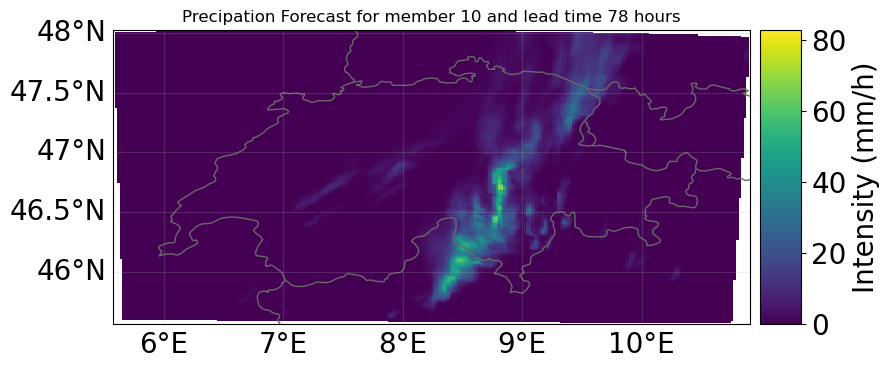

In [104]:
# plot hazard forecast for one member  and one lead time
id_member = 10
id_lead_time = 78
ax = hazard_forecast.select(
    member=hazard_forecast.member[id_member],
    lead_time=np.unique(hazard_forecast.lead_time)[id_lead_time],
).plot_intensity(0)
ax.set_title(
    f"Precipation Forecast for member {hazard_forecast.member[id_member]} and lead time {np.unique(hazard_forecast.lead_time)[id_lead_time].astype('timedelta64[h]')}"
)

In [ ]:
# plot median over member dimension for given a lead time
id_lead_time = 5
ax = (
    hazard_forecast.max(dimension="member")
    .select(lead_time=impact_forecast.lead_time[id_lead_time])
    .plot_intensity(0)
)
ax.set_title(
    f"Hazard Forecast for member {impact_forecast.member[id_member]} and lead time {impact_forecast.lead_time[id_lead_time]}"
)

## Impact calculation

2025-12-10 15:24:09,958 - climada.entity.exposures.litpop.litpop - INFO - 
 LitPop: Init Exposure for country: CHE (756)...

2025-12-10 15:24:10,199 - climada.entity.exposures.litpop.litpop - INFO - 
 LitPop: Init Exposure for country: LIE (438)...

2025-12-10 15:24:10,272 - climada.entity.exposures.base - INFO - Hazard type not set in impf_
2025-12-10 15:24:10,272 - climada.entity.exposures.base - INFO - category_id not set.
2025-12-10 15:24:10,272 - climada.entity.exposures.base - INFO - cover not set.
2025-12-10 15:24:10,273 - climada.entity.exposures.base - INFO - deductible not set.
2025-12-10 15:24:10,273 - climada.entity.exposures.base - INFO - centr_ not set.
2025-12-10 15:24:10,284 - climada.entity.exposures.base - INFO - Matching 70525 exposures with 27000 centroids.
2025-12-10 15:24:10,349 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 100 degree


<Axes: title={'center': 'PR 1: '}, xlabel='Intensity ()', ylabel='Impact (%)'>

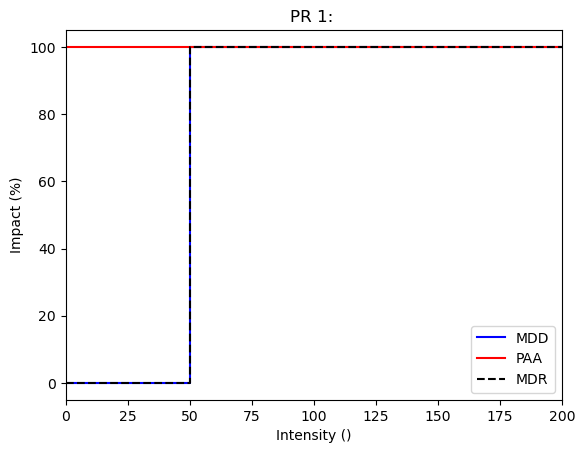

In [89]:
# Read exposure for population
exp_che = LitPop.from_population(countries=["CHE", "LIE"], res_arcsec=30)

# Assign centroids because hazard not on regular grid
exp_che.assign_centroids(hazard_forecast, threshold=100)

# define impact functions
imp_fun_precip = ImpactFunc.from_step_impf((0, 50, 200), haz_type=f"PR", impf_id=1)

impf_set = ImpactFuncSet([imp_fun_precip])
impf_set.plot()

In [90]:
# calculate impact
# assign_centroid=False because we do not want to reassign centroids
impact_forecast = ImpactCalc(exp_che, impf_set, hazard_forecast).impact(
    save_mat=True, assign_centroids=False
)

2025-12-10 15:24:22,229 - climada.entity.exposures.base - INFO - No specific impact function column found for hazard PR. Using the anonymous 'impf_' column.
2025-12-10 15:24:22,234 - climada.engine.impact_calc - INFO - Calculating impact for 208182 assets (>0) and 2415 events.
2025-12-10 15:24:22,572 - climada.engine.impact_calc - WARNING - eai_exp and aai_agg are undefined with forecasts. Setting them to NaN arrays.
2025-12-10 15:24:22,586 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold
2025-12-10 15:24:22,587 - climada.engine.impact_forecast - WARNING - at_event gives the total impact for one specific combination of member and lead_time.


In [94]:
impact_forecast.imp_mat

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 9126 stored elements and shape (2415, 70525)>

## Forecast products based on ImpactForecast

In [ ]:
impact_forecast.imp_mat

np.int64(0)

In [105]:
# plot impact forecast for member 0 and shortest lead time

id_member = 10
id_lead_time = 78
impact_forecast.select(
    member=hazard_forecast.member[id_member],
    lead_time=np.unique(hazard_forecast.lead_time)[id_lead_time],
).plot_hexbin_impact_exposure()

2025-12-10 15:29:16,486 - climada.engine.impact - INFO - The eai_exp and aai_agg are computed for the selected subset of events WITHOUT modification of the frequencies.


ValueError: not enough values to unpack (expected 1, got 0)

In [ ]:
average_total_impact_per_leadtime = impact_forecast.mean(
    dimension="member"
).imp_mat.sum(axis=1)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(impact_forecast.lead_time, average_total_impact_per_leadtime)
ax.set_xlabel("Lead time")
ax.set_ylabel("Number of people")
ax.set_title("Number of impacted people in CH per lead time (ensemble average)")

In [ ]:
# per member map of maximum precip over leatimes

# plt.subplots(7, 3, )

In [ ]:
# per lead time histogram over members aggrevated over switzerland

# plt.subplots(7, 3, )

In [42]:
# show that some methods and attributes are blocked

### Download and save data from MeteoSwiss Open Government Data

In [ ]:
# # Define target lead times ICON2: 5d, here +0h, to +12h
# lead_times = [f"P0DT{i}H" for i in np.arange(0, 13)] #[f"P0DT{i}H" for i in np.arange(0, 49)]
# model = "ogd-forecasting-icon-ch2"
# nwp_vars = ["TOT_PREC", 'VMAX_10M'] #["TOT_PREC", "T_2M", 'VMAX_10M']

In [ ]:
# # request download
# dict_ens_data = {}
# for var in nwp_vars:
#     req = ogd_api.Request(
#         collection=model,
#         variable=var,
#         ref_time="latest",
#         perturbed=True,  #ensembles
#         lead_time=lead_times,
#     )
#     dict_ens_data[var] = ogd_api.get_from_ogd(req)

# dict_ens_data['TOT_PREC'] = time_ops.delta(dict_ens_data['TOT_PREC'],
#                                            np.timedelta64(1, "h"))

earthkit-data cache: trying to free 9.2 GiB
earthkit-data cache: could not free 9.2 GiB
earthkit-data cache: trying to free 9.2 GiB                                                                                                                        
Deleting entry {
    "path": "/var/folders/04/tbpkdd855mg6mjr2mj6h1csh0000gp/T/tmpeoqrneh9/url-ee32bffcbba08f895214426a49cf6f6b1ef54991a555a8f132a75d254cd89ae3.unknown",
    "owner": "url",
    "args": {
        "url": [
            "https://rgw.cscs.ch/cscs.meteoswiss.ogd.nwp/icon-ch2-eps-202512100600-0-tot_prec-perturb.grib2?AWSAccessKeyId=13GC1T4NT2CY1N0L92YC&Signature=l27Sl7nKM0Ddn39i4OdvOKjW8f0%3D&Expires=1765439828",
            "https://rgw.cscs.ch/cscs.meteoswiss.ogd.nwp/icon-ch2-eps-202512100600-1-tot_prec-perturb.grib2?AWSAccessKeyId=13GC1T4NT2CY1N0L92YC&Signature=LTBWilJ8B3UNiURWNWkHkvg6BBQ%3D&Expires=1765440054",
            "https://rgw.cscs.ch/cscs.meteoswiss.ogd.nwp/icon-ch2-eps-202512100600-2-tot_prec-perturb.grib2?AWSAcce

In [ ]:
# # helper function for cleaning downloaded data
# def clean_attrs(data_array):
#     """
#     Recursively cleans all attributes in a DataArray (data, coordinates, and encoding).
#     """
#     valid_types = (str, numbers.Number, np.ndarray, list, tuple, bytes,
#                    type(None), np.integer, np.floating)

#     # Clean main data attributes
#     data_array.attrs = {
#         k: v
#         for k, v in data_array.attrs.items() if isinstance(v, valid_types)
#     }

#     # Clean coordinate attributes
#     for coord_name in data_array.coords:
#         coord = data_array.coords[coord_name]
#         problematic = [
#             k for k, v in coord.attrs.items()
#             if not isinstance(v, valid_types)
#         ]
#         for key in problematic:
#             print(
#                 f"Removing coord attr '{coord_name}.{key}': {type(coord.attrs[key])}"
#             )
#             del coord.attrs[key]

#     # Clean encoding
#     data_array.encoding = {
#         k: v
#         for k, v in data_array.encoding.items() if isinstance(v, valid_types)
#     }

#     return data_array

In [ ]:
# data_path = data_dir_hazard_forecast.joinpath("icon")
# data_path.mkdir(parents=True, exist_ok=True)

# for var, data in dict_ens_data.items():
#     data = clean_attrs(data)
#     data.to_netcdf(data_path / f"icon-ch2-ens-{var.lower()}-latest.nc")

In [ ]:
# Using MeteoSwiss Open Government Data weather forecasts

# hazard_forecast = HazardForecast.from_xarray()
# Forecast data on